In [5]:
!pip install pmdarima
!pip install openmeteo-requests

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

In [8]:
df.head()

,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50401 entries, 0 to 50400
Columns: 300 entries, utc_timestamp to UA_load_forecast_entsoe_transparency
dtypes: float64(298), object(2)
memory usage: 115.4+ MB


In [10]:
df.shape

(50401, 300)

In [11]:
for col in df.columns:
    if "DE" in col:
        print(col)

DE_load_actual_entsoe_transparency
DE_load_forecast_entsoe_transparency
DE_solar_capacity
DE_solar_generation_actual
DE_solar_profile
DE_wind_capacity
DE_wind_generation_actual
DE_wind_profile
DE_wind_offshore_capacity
DE_wind_offshore_generation_actual
DE_wind_offshore_profile
DE_wind_onshore_capacity
DE_wind_onshore_generation_actual
DE_wind_onshore_profile
DE_50hertz_load_actual_entsoe_transparency
DE_50hertz_load_forecast_entsoe_transparency
DE_50hertz_solar_generation_actual
DE_50hertz_wind_generation_actual
DE_50hertz_wind_offshore_generation_actual
DE_50hertz_wind_onshore_generation_actual
DE_LU_load_actual_entsoe_transparency
DE_LU_load_forecast_entsoe_transparency
DE_LU_price_day_ahead
DE_LU_solar_generation_actual
DE_LU_wind_generation_actual
DE_LU_wind_offshore_generation_actual
DE_LU_wind_onshore_generation_actual
DE_amprion_load_actual_entsoe_transparency
DE_amprion_load_forecast_entsoe_transparency
DE_amprion_solar_generation_actual
DE_amprion_wind_onshore_generation_actu

In [12]:
df = df[['utc_timestamp', 'DE_load_actual_entsoe_transparency']]

In [13]:
df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'])
df.set_index('utc_timestamp', inplace=True)

In [14]:
df = df.loc['2015-01-01':'2020-10-31']

In [15]:
df.isnull().sum()

,0
DE_load_actual_entsoe_transparency,0


In [16]:
df = df.dropna()

In [17]:
df.shape

(50400, 1)

In [18]:
daily_df = df.resample('D').sum()
weekly_df = df.resample('W').sum()

In [19]:
print("Daily Shape:", daily_df.shape)
print("Weekly Shape:", weekly_df.shape)

daily_df.head()
weekly_df.head()

Daily Shape: (2100, 1)
Weekly Shape: (301, 1)


,DE_load_actual_entsoe_transparency
utc_timestamp,
2015-01-04 00:00:00+00:00,4534439.0
2015-01-11 00:00:00+00:00,9440105.0
2015-01-18 00:00:00+00:00,9689010.0
2015-01-25 00:00:00+00:00,9847035.0
2015-02-01 00:00:00+00:00,9867317.0


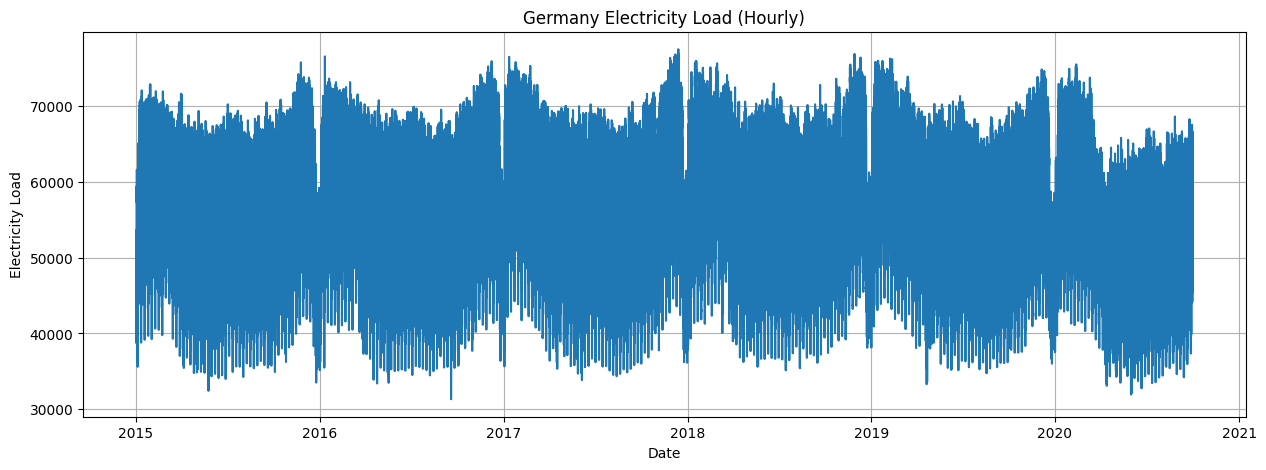

In [20]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df['DE_load_actual_entsoe_transparency'])
plt.title("Germany Electricity Load (Hourly)")
plt.xlabel("Date")
plt.ylabel("Electricity Load")
plt.grid(True)
plt.show()

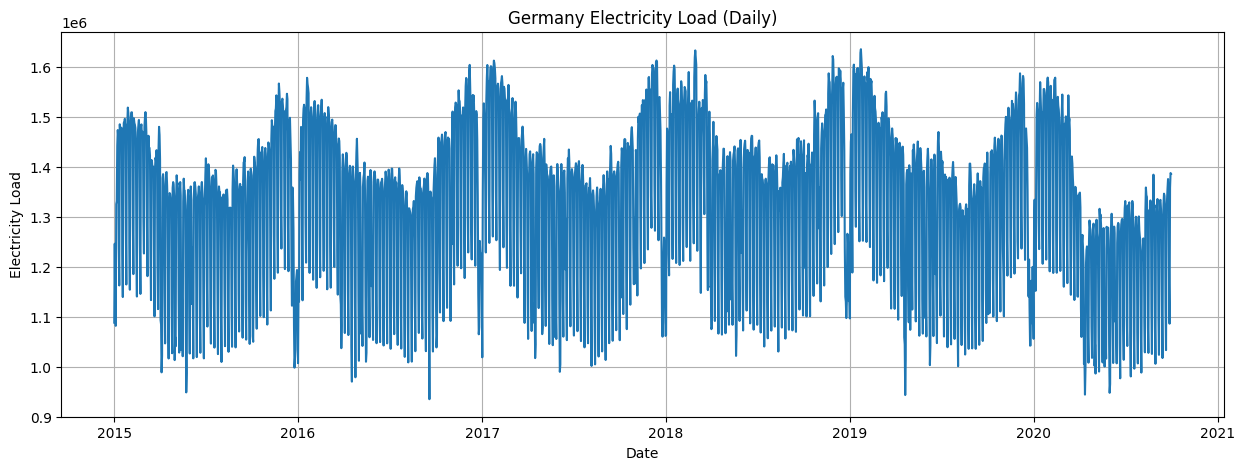

In [21]:
plt.figure(figsize=(15,5))
plt.plot(daily_df.index, daily_df['DE_load_actual_entsoe_transparency'])
plt.title("Germany Electricity Load (Daily)")
plt.xlabel("Date")
plt.ylabel("Electricity Load")
plt.grid(True)
plt.show()

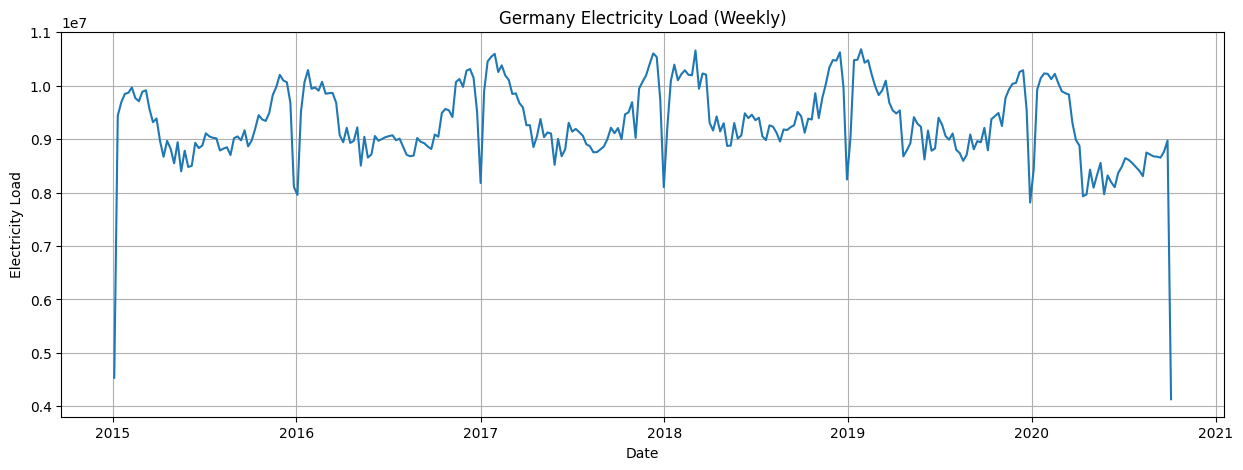

In [22]:
plt.figure(figsize=(15,5))
plt.plot(weekly_df.index, weekly_df['DE_load_actual_entsoe_transparency'])
plt.title("Germany Electricity Load (Weekly)")
plt.xlabel("Date")
plt.ylabel("Electricity Load")
plt.grid(True)
plt.show()

In [23]:
daily_df.describe()

,DE_load_actual_entsoe_transparency
count,2.100000e+03
mean,1.331819e+06
std,1.584354e+05
min,9.348640e+05
25%,1.209923e+06
50%,1.362646e+06
75%,1.450322e+06
max,1.636406e+06


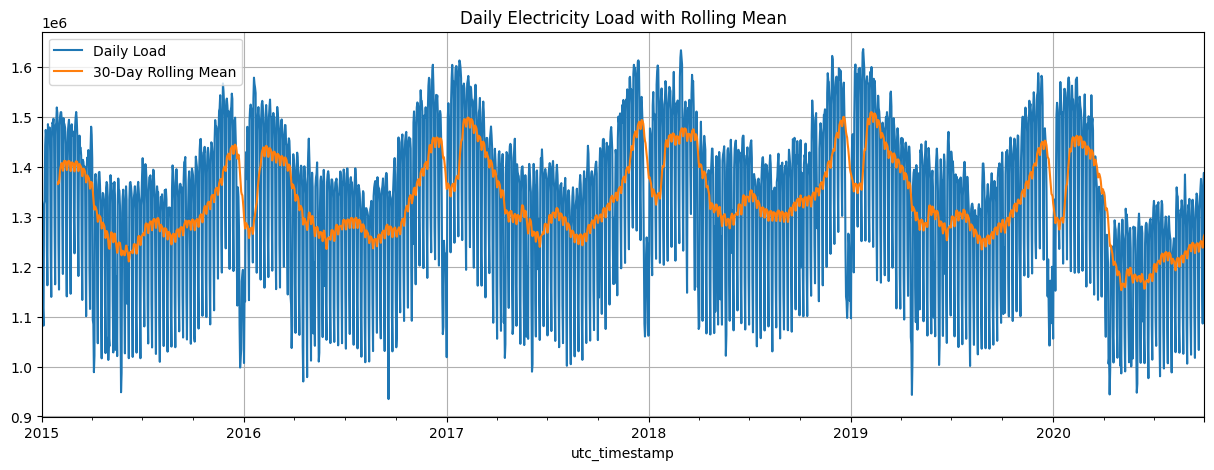

In [24]:
plt.figure(figsize=(15,5))

daily_df['DE_load_actual_entsoe_transparency'].plot(label='Daily Load')

daily_df['DE_load_actual_entsoe_transparency'].rolling(window=30).mean().plot(label='30-Day Rolling Mean')

plt.title("Daily Electricity Load with Rolling Mean")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_df['DE_load_actual_entsoe_transparency'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Data is Stationary")
else:
    print("Data is Non-Stationary")

ADF Statistic: -4.593460971848515
p-value: 0.00013280221269338624
Data is Stationary


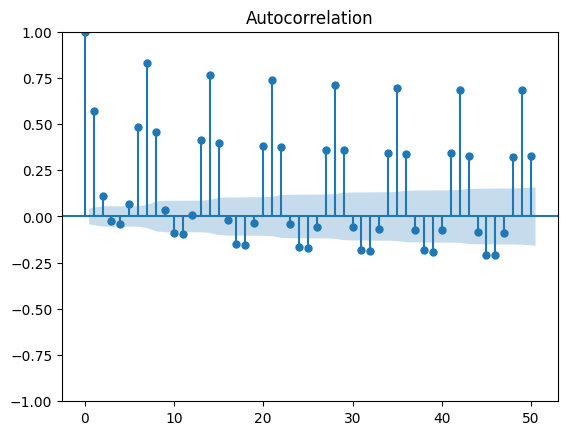

In [26]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(daily_df['DE_load_actual_entsoe_transparency'], lags=50)
plt.show()

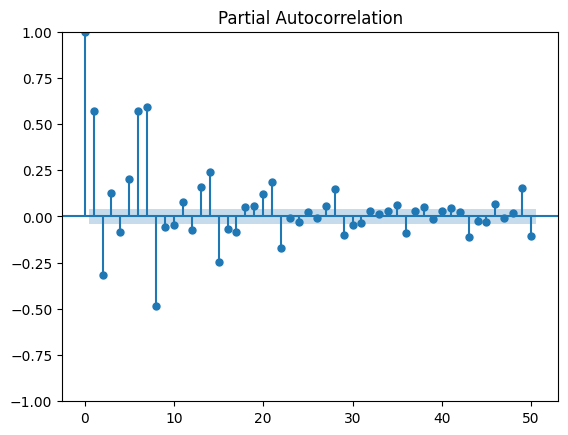

In [27]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(daily_df['DE_load_actual_entsoe_transparency'], lags=50)
plt.show()

In [28]:
daily_diff = daily_df.diff().dropna()

In [29]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_diff['DE_load_actual_entsoe_transparency'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Data is Stationary")
else:
    print("Data is Non-Stationary")

ADF Statistic: -14.222943172107607
p-value: 1.64580302433402e-26
Data is Stationary


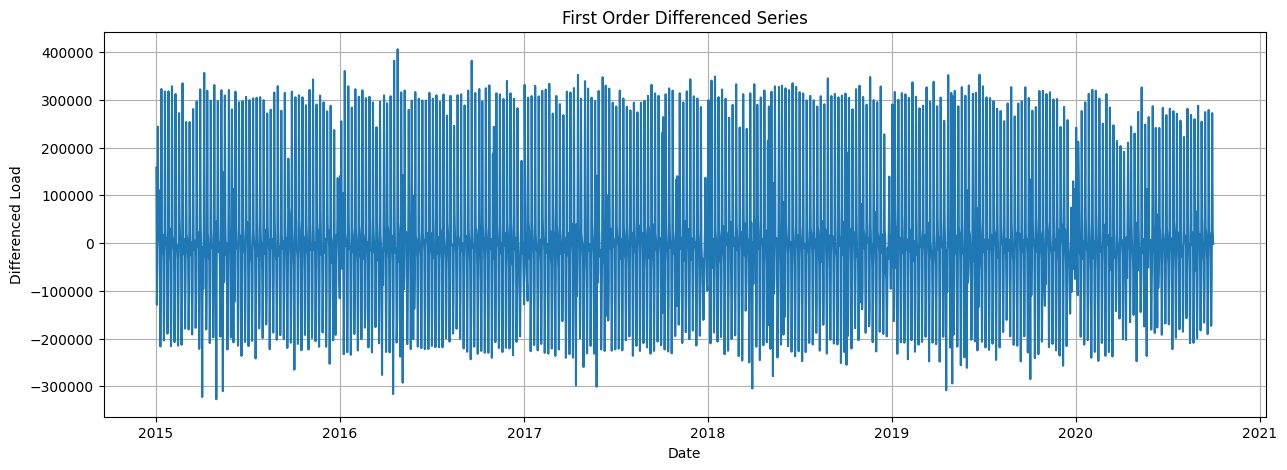

In [30]:
plt.figure(figsize=(15,5))
plt.plot(daily_diff.index, daily_diff['DE_load_actual_entsoe_transparency'])
plt.title("First Order Differenced Series")
plt.xlabel("Date")
plt.ylabel("Differenced Load")
plt.grid(True)
plt.show()

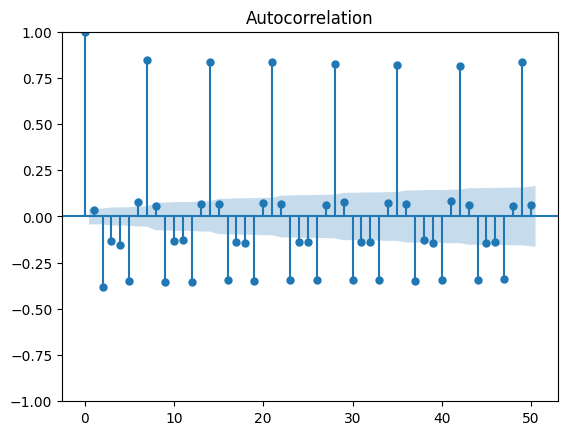

In [31]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(daily_diff['DE_load_actual_entsoe_transparency'], lags=50)
plt.show()

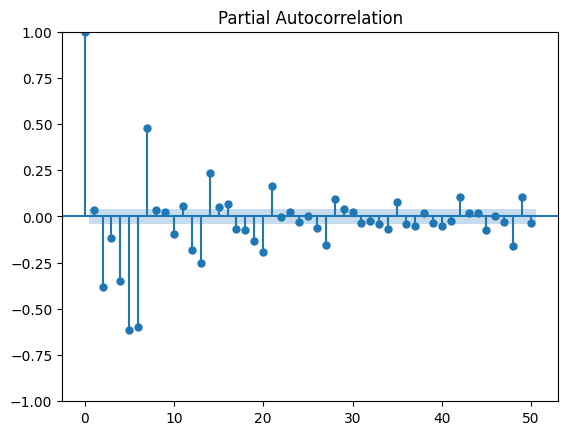

In [32]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(daily_diff['DE_load_actual_entsoe_transparency'], lags=50)
plt.show()

In [35]:
from statsforecast import StatsForecast
from statsforecast.models import HistoricAverage, Naive, SeasonalNaive, RandomWalkWithDrift

In [36]:
train = daily_df[:-730]
test = daily_df[-730:]

print(train.shape)
print(test.shape)

(1370, 1)
(730, 1)


In [38]:
sf_train = train.reset_index()

sf_train.columns = ['ds', 'y']

sf_train['unique_id'] = 'Germany'

sf_train = sf_train[['unique_id', 'ds', 'y']]

sf_train.head()

,unique_id,ds,y
0,Germany,2015-01-01 00:00:00+00:00,1088317.0
1,Germany,2015-01-02 00:00:00+00:00,1246588.0
2,Germany,2015-01-03 00:00:00+00:00,1117554.0
3,Germany,2015-01-04 00:00:00+00:00,1081980.0
4,Germany,2015-01-05 00:00:00+00:00,1325920.0


In [39]:
models = [
    HistoricAverage(),
    Naive(),
    SeasonalNaive(season_length=7),
    RandomWalkWithDrift()
]

In [40]:
sf = StatsForecast(
    models=models,
    freq='D'
)

sf.fit(sf_train)

StatsForecast(models=[HistoricAverage,Naive,SeasonalNaive,RWD])

In [41]:
forecast = sf.predict(h=730)

forecast.head()

,unique_id,ds,HistoricAverage,Naive,SeasonalNaive,RWD
0,Germany,2018-10-02 00:00:00+00:00,1.336281e+06,1416219.0,1407105.0,1.416459e+06
1,Germany,2018-10-03 00:00:00+00:00,1.336281e+06,1416219.0,1451959.0,1.416698e+06
2,Germany,2018-10-04 00:00:00+00:00,1.336281e+06,1416219.0,1426402.0,1.416938e+06
3,Germany,2018-10-05 00:00:00+00:00,1.336281e+06,1416219.0,1422547.0,1.417177e+06
4,Germany,2018-10-06 00:00:00+00:00,1.336281e+06,1416219.0,1194314.0,1.417417e+06


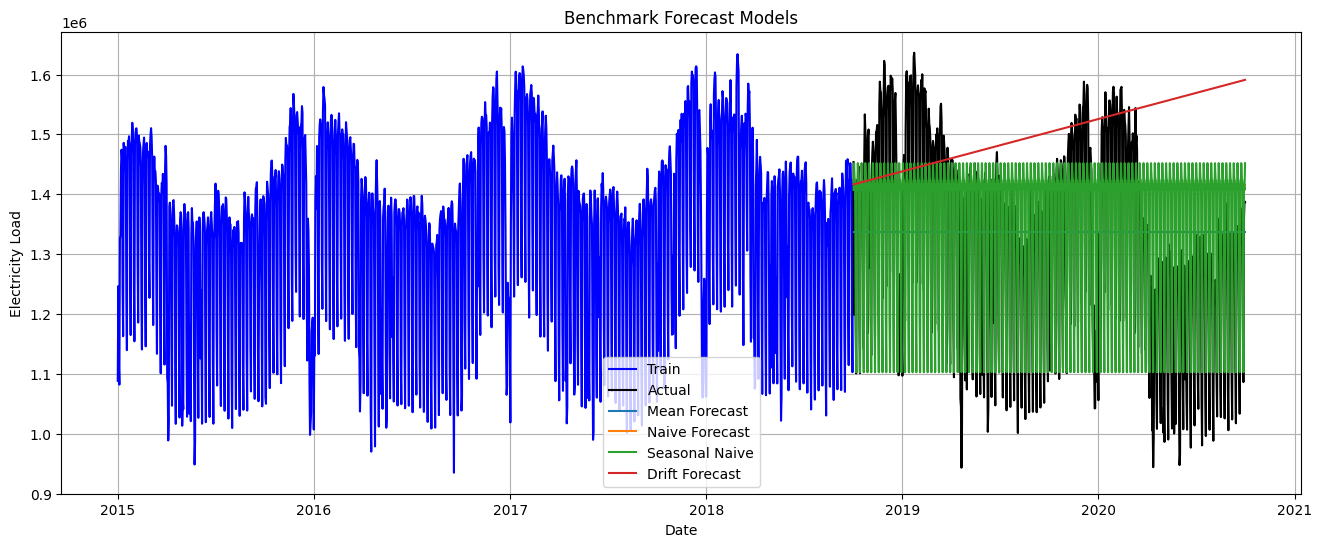

In [42]:
plt.figure(figsize=(16,6))

plt.plot(train.index, train.iloc[:,0], label='Train', color='blue')

plt.plot(test.index, test.iloc[:,0], label='Actual', color='black')

plt.plot(test.index, forecast['HistoricAverage'], label='Mean Forecast')

plt.plot(test.index, forecast['Naive'], label='Naive Forecast')

plt.plot(test.index, forecast['SeasonalNaive'], label='Seasonal Naive')

plt.plot(test.index, forecast['RWD'], label='Drift Forecast')

plt.title("Benchmark Forecast Models")
plt.xlabel("Date")
plt.ylabel("Electricity Load")
plt.legend()
plt.grid(True)

plt.show()

In [44]:
results = pd.DataFrame(columns=['Model','MAE','RMSE'])

models = {
    'HistoricAverage': forecast['HistoricAverage'],
    'Naive': forecast['Naive'],
    'SeasonalNaive': forecast['SeasonalNaive'],
    'RandomWalkWithDrift': forecast['RWD']
}

for name, pred in models.items():

    mae = mean_absolute_error(test.iloc[:,0], pred)

    rmse = np.sqrt(mean_squared_error(test.iloc[:,0], pred))

    results.loc[len(results)] = [name, mae, rmse]

results

,Model,MAE,RMSE
0,HistoricAverage,135633.757034,164367.576212
1,Naive,150598.649315,188305.467660
2,SeasonalNaive,96737.043836,120483.333450
3,RandomWalkWithDrift,208574.918787,259750.398126


In [45]:
results.sort_values(by='RMSE')

,Model,MAE,RMSE
2,SeasonalNaive,96737.043836,120483.333450
0,HistoricAverage,135633.757034,164367.576212
1,Naive,150598.649315,188305.467660
3,RandomWalkWithDrift,208574.918787,259750.398126


In [46]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
import warnings

warnings.filterwarnings("ignore")

In [47]:
p = range(0,3)
d = range(0,3)
q = range(0,3)

best_aic = float("inf")
best_order = None

for order in product(p, d, q):
    try:
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=(1,1,1,7)
        )

        result = model.fit(disp=False)

        if result.aic < best_aic:
            best_aic = result.aic
            best_order = order

    except:
        continue

print("Best Order:", best_order)
print("Best AIC:", best_aic)

Best Order: (2, 0, 2)
Best AIC: 33872.338551054825


In [48]:
model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=(1,1,1,7)
)

sarima = model.fit()

print(sarima.summary())

                                       SARIMAX Results                                        
Dep. Variable:     DE_load_actual_entsoe_transparency   No. Observations:                 1370
Model:                SARIMAX(2, 0, 2)x(1, 1, [1], 7)   Log Likelihood              -16929.169
Date:                                Mon, 13 Jul 2026   AIC                          33872.339
Time:                                        04:58:25   BIC                          33908.861
Sample:                                    01-01-2015   HQIC                         33886.010
                                         - 10-01-2018                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1146      0.097     11.511      0.000       0.925       1.304
ar.

In [49]:
sarima_pred = sarima.forecast(steps=730)

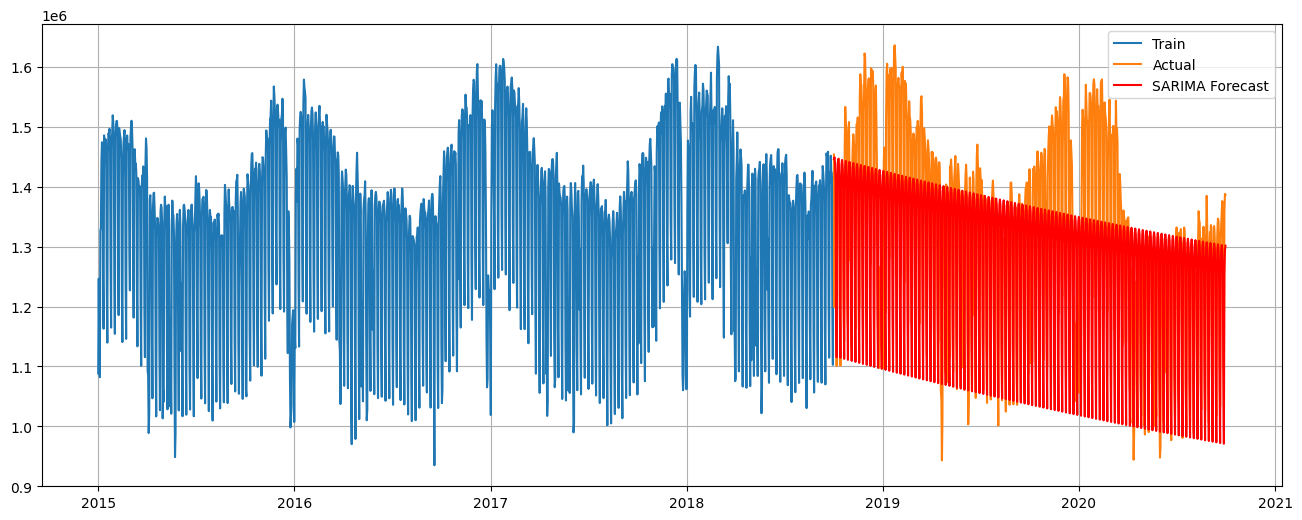

In [50]:
plt.figure(figsize=(16,6))

plt.plot(train.index, train.iloc[:,0], label='Train')

plt.plot(test.index, test.iloc[:,0], label='Actual')

plt.plot(test.index, sarima_pred, label='SARIMA Forecast', color='red')

plt.legend()

plt.grid(True)

plt.show()

In [51]:
mae = mean_absolute_error(test.iloc[:,0], sarima_pred)

rmse = np.sqrt(mean_squared_error(test.iloc[:,0], sarima_pred))

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 86950.2569692416
RMSE: 115197.16216037565


In [54]:
import openmeteo_requests
import requests_cache
from retry_requests import retry

cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

In [55]:
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 52.52,
    "longitude": 13.41,
    "start_date": "2015-01-01",
    "end_date": "2020-10-31",
    "daily": "temperature_2m_mean",
    "timezone": "UTC"
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]

In [56]:
import pandas as pd

daily = response.Daily()

temp_df = pd.DataFrame({
    "Date": pd.date_range(
        start=pd.to_datetime(daily.Time(), unit="s"),
        end=pd.to_datetime(daily.TimeEnd(), unit="s"),
        freq="D",
        inclusive="left"
    ),
    "Temperature": daily.Variables(0).ValuesAsNumpy()
})

temp_df.head()

,Date,Temperature
0,2015-01-01,2.595250
1,2015-01-02,4.857750
2,2015-01-03,3.780667
3,2015-01-04,2.841083
4,2015-01-05,2.878583


In [58]:
daily_load["Date"] = daily_load["Date"].dt.tz_localize(None)
temp_df["Date"] = pd.to_datetime(temp_df["Date"])

In [59]:
merged = pd.merge(
    daily_load,
    temp_df,
    on="Date",
    how="inner"
)

merged.head()

,Date,Load,Temperature
0,2015-01-01,1088317.0,2.595250
1,2015-01-02,1246588.0,4.857750
2,2015-01-03,1117554.0,3.780667
3,2015-01-04,1081980.0,2.841083
4,2015-01-05,1325920.0,2.878583


In [60]:
train = merged[:-730]
test = merged[-730:]

print(train.shape)
print(test.shape)

(1370, 3)
(730, 3)


In [61]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_model = SARIMAX(
    train["Load"],
    exog=train[["Temperature"]],
    order=best_order,
    seasonal_order=(1,1,1,7)
)

sarimax_result = sarimax_model.fit()

print(sarimax_result.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                Load   No. Observations:                 1370
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 7)   Log Likelihood              -16930.283
Date:                             Mon, 13 Jul 2026   AIC                          33876.566
Time:                                     05:02:48   BIC                          33918.306
Sample:                                          0   HQIC                         33892.190
                                            - 1370                                         
Covariance Type:                               opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Temperature  -906.8244   1089.258     -0.833      0.405   -3041.732    1228.083
ar.L1           1.1123  

In [62]:
sarimax_forecast = sarimax_result.forecast(
    steps=len(test),
    exog=test[["Temperature"]]
)

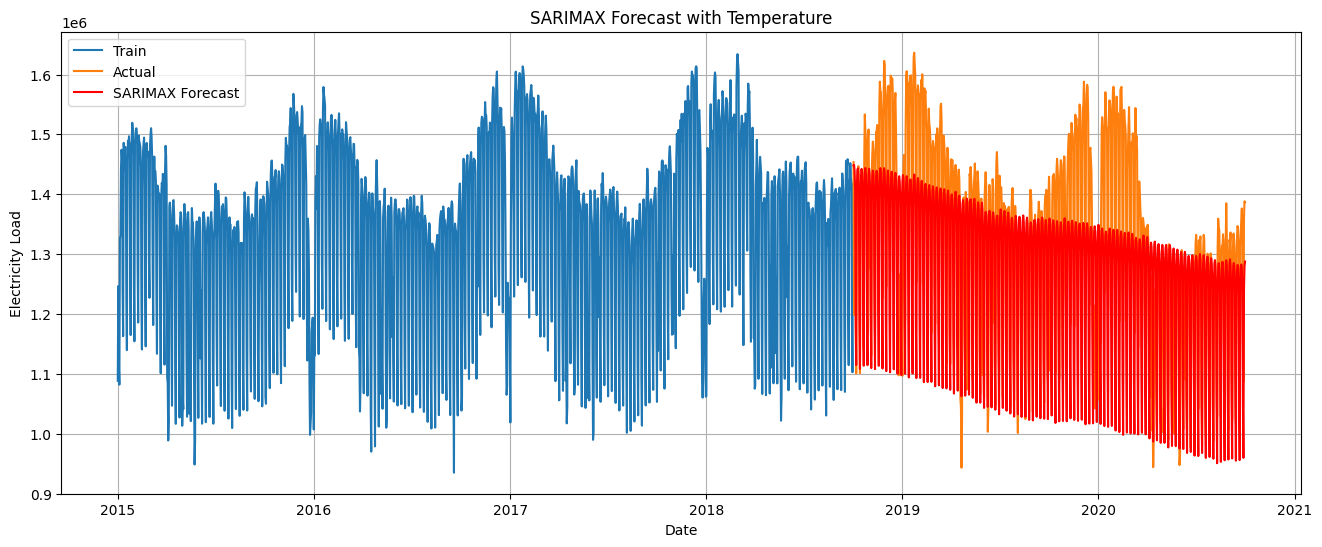

In [63]:
plt.figure(figsize=(16,6))

plt.plot(train["Date"], train["Load"], label="Train")
plt.plot(test["Date"], test["Load"], label="Actual")
plt.plot(test["Date"], sarimax_forecast, label="SARIMAX Forecast", color="red")

plt.title("SARIMAX Forecast with Temperature")
plt.xlabel("Date")
plt.ylabel("Electricity Load")
plt.legend()
plt.grid(True)

plt.show()

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test["Load"], sarimax_forecast)
rmse = np.sqrt(mean_squared_error(test["Load"], sarimax_forecast))

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 89331.81128162051
RMSE: 116145.8638067335


In [65]:
feature_df = merged.copy()

feature_df["Day"] = feature_df["Date"].dt.day
feature_df["Month"] = feature_df["Date"].dt.month
feature_df["Year"] = feature_df["Date"].dt.year
feature_df["Weekday"] = feature_df["Date"].dt.dayofweek
feature_df["Week"] = feature_df["Date"].dt.isocalendar().week.astype(int)

feature_df.head()

,Date,Load,Temperature,Day,Month,Year,Weekday,Week
0,2015-01-01,1088317.0,2.595250,1,1,2015,3,1
1,2015-01-02,1246588.0,4.857750,2,1,2015,4,1
2,2015-01-03,1117554.0,3.780667,3,1,2015,5,1
3,2015-01-04,1081980.0,2.841083,4,1,2015,6,1
4,2015-01-05,1325920.0,2.878583,5,1,2015,0,2


In [66]:
feature_df["Lag1"] = feature_df["Load"].shift(1)
feature_df["Lag7"] = feature_df["Load"].shift(7)
feature_df["Lag30"] = feature_df["Load"].shift(30)

feature_df = feature_df.dropna()

feature_df.head()

,Date,Load,Temperature,Day,Month,Year,Weekday,Week,Lag1,Lag7,Lag30
30,2015-01-31,1249019.0,-0.031833,31,1,2015,5,5,1464840.0,1281112.0,1088317.0
31,2015-02-01,1154355.0,0.580667,1,2,2015,6,5,1249019.0,1164822.0,1246588.0
32,2015-02-02,1483039.0,0.422333,2,2,2015,0,6,1154355.0,1482870.0,1117554.0
33,2015-02-03,1502037.0,-0.786000,3,2,2015,1,6,1483039.0,1488375.0,1081980.0
34,2015-02-04,1509819.0,-2.229750,4,2,2015,2,6,1502037.0,1519415.0,1325920.0


In [67]:
train = feature_df[:-730]
test = feature_df[-730:]

In [68]:
X_train = train.drop(columns=["Date","Load"])
y_train = train["Load"]

X_test = test.drop(columns=["Date","Load"])
y_test = test["Load"]

In [69]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [70]:
rf_pred = rf.predict(X_test)

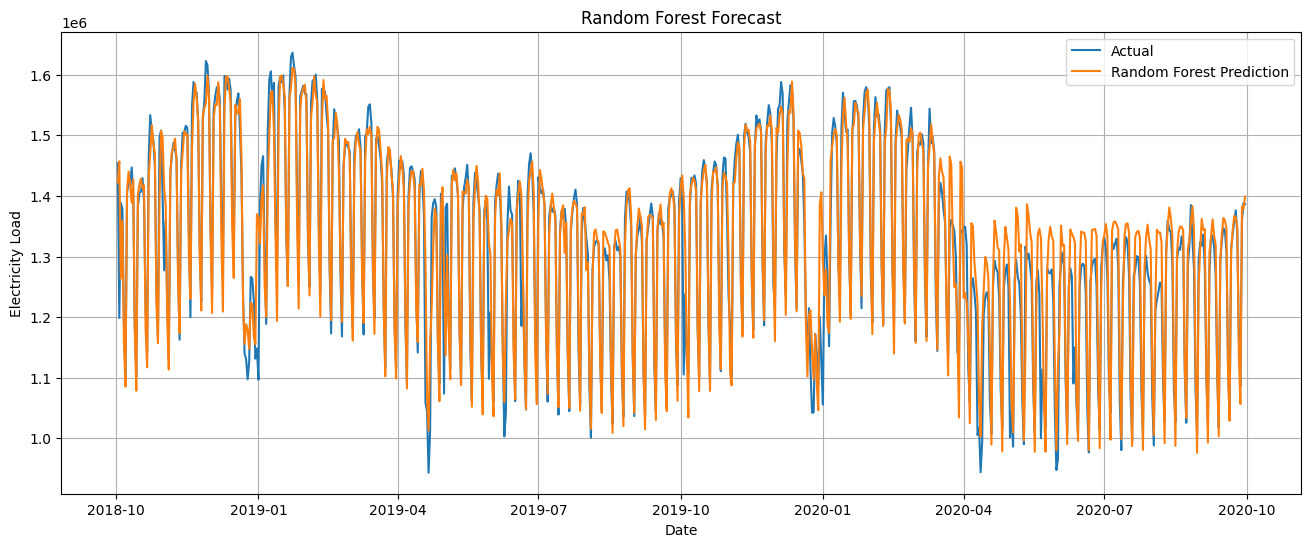

In [71]:
plt.figure(figsize=(16,6))

plt.plot(test["Date"], y_test, label="Actual")

plt.plot(test["Date"], rf_pred, label="Random Forest Prediction")

plt.title("Random Forest Forecast")

plt.xlabel("Date")

plt.ylabel("Electricity Load")

plt.legend()

plt.grid(True)

plt.show()

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 34546.973924657534
RMSE: 54487.208202542395


In [73]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

       Feature  Importance
4      Weekday    0.609726
6         Lag1    0.246814
7         Lag7    0.048056
5         Week    0.033794
0  Temperature    0.023786
8        Lag30    0.019401
1          Day    0.011207
2        Month    0.004470
3         Year    0.002747


In [74]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np

In [75]:
load_data = merged[['Load']].values

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(load_data)

In [76]:
sequence_length = 30

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(2070, 30, 1)
(2070, 1)


In [77]:
split = len(X) - 730

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [78]:
model = Sequential()

model.add(LSTM(64, return_sequences=True,
               input_shape=(X_train.shape[1],1)))

model.add(LSTM(32))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - loss: 0.0682 - val_loss: 0.0384
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0441 - val_loss: 0.0385
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0440 - val_loss: 0.0387
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0437 - val_loss: 0.0383
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0437 - val_loss: 0.0383
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0447 - val_loss: 0.0384
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0435 - val_loss: 0.0381
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0440 - val_loss: 0.0434
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0447 - val_loss: 0.0383
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0432 - val_loss: 0.0376
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0429 - val_loss: 0.0372
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0

In [80]:
pred = model.predict(X_test)

pred = scaler.inverse_transform(pred)

actual = scaler.inverse_transform(y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step


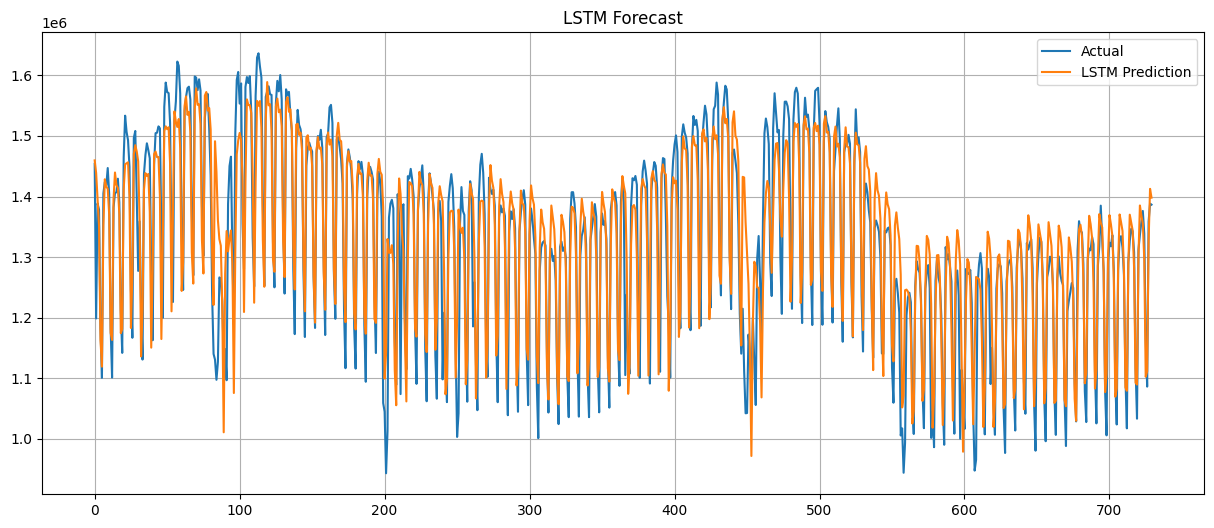

In [81]:
plt.figure(figsize=(15,6))

plt.plot(actual,label='Actual')

plt.plot(pred,label='LSTM Prediction')

plt.title("LSTM Forecast")

plt.legend()

plt.grid(True)

plt.show()

In [82]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(actual,pred)

rmse = np.sqrt(mean_squared_error(actual,pred))

print("MAE :",mae)

print("RMSE :",rmse)

MAE : 52436.67174657534
RMSE : 75725.0283012029


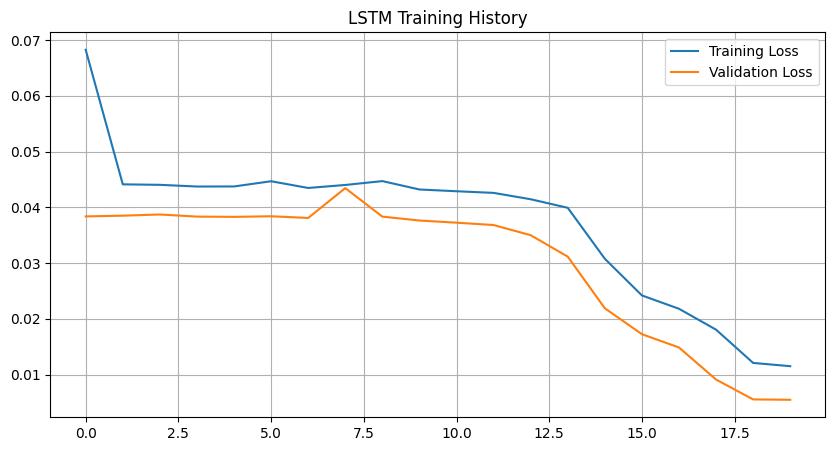

In [83]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],label='Training Loss')

plt.plot(history.history['val_loss'],label='Validation Loss')

plt.title("LSTM Training History")

plt.legend()

plt.grid(True)

plt.show()

In [87]:
comparison = pd.DataFrame({
    "Model": [
        "Seasonal Naive",
        "SARIMA",
        "SARIMAX",
        "Random Forest",
        "LSTM"
    ],
    "RMSE": [
        120483.333450,      # Seasonal Naive
        115197.162160,      # SARIMA
        116145.863807,      # SARIMAX
        54487.208203,       # Random Forest
        75725.028301        # LSTM
    ]
})

comparison = comparison.sort_values(by="RMSE")
comparison

,Model,RMSE
3,Random Forest,54487.208203
4,LSTM,75725.028301
1,SARIMA,115197.162160
2,SARIMAX,116145.863807
0,Seasonal Naive,120483.333450
